In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv("data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
df.shape

(8807, 12)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [20]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [21]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [23]:
# Fill missing values

df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna("Unknown")

df["duration"] = df["duration"].fillna("Unknown")

df["date_added"] = df["date_added"].fillna("Unknown")

In [24]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [27]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

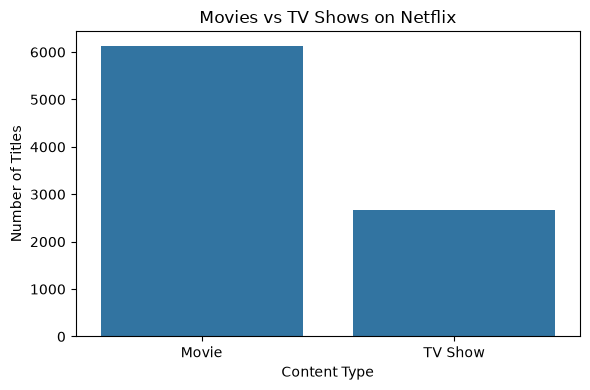

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("images/movie_tv_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

In [32]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

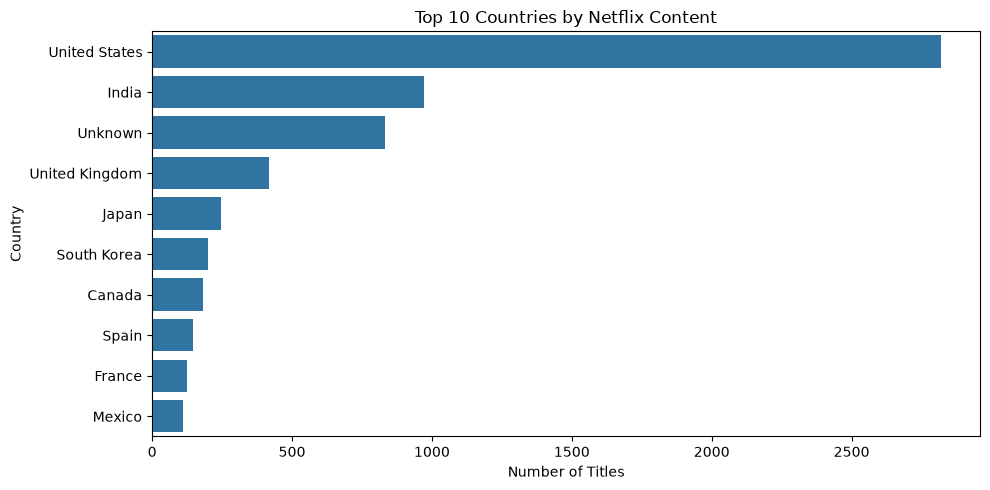

In [33]:
plt.figure(figsize=(10,5))

country_counts = df["country"].value_counts().head(10)

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("images/top_countries.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

In [34]:
df["release_year"].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

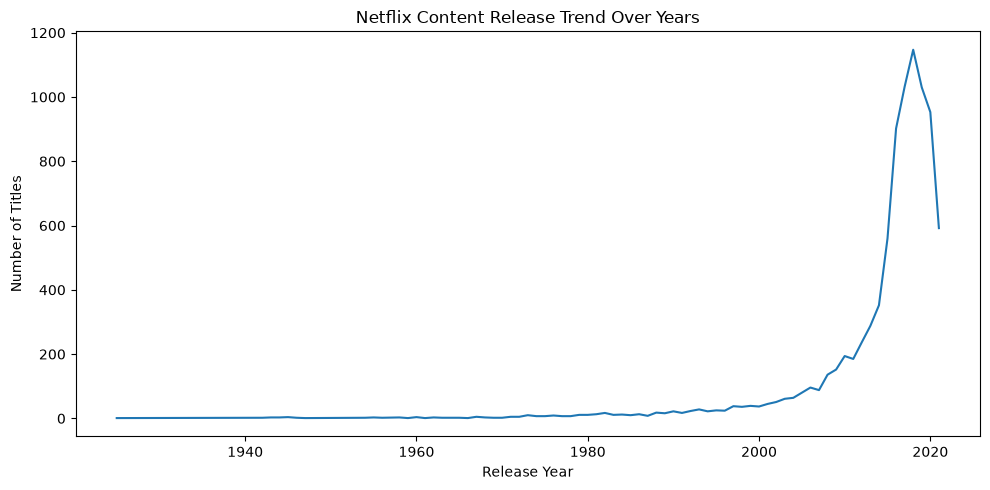

In [35]:
plt.figure(figsize=(10,5))

year_counts = df["release_year"].value_counts().sort_index()

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title("Netflix Content Release Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("images/content_release_trend.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

In [36]:
# Split genres and count each genre

genres = df["listed_in"].str.split(", ")

genre_counts = genres.explode().value_counts()

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

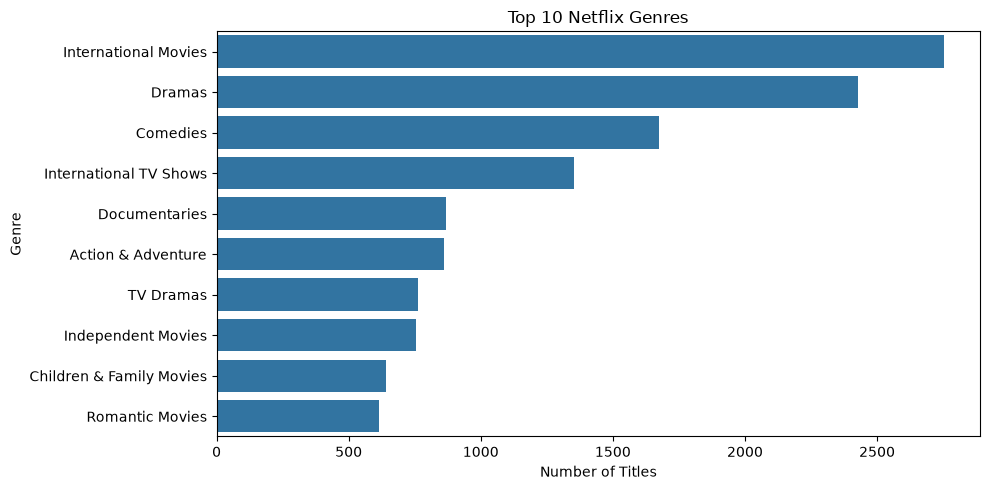

In [37]:
plt.figure(figsize=(10,5))

top_genres = genre_counts.head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()

plt.savefig("images/top_genres.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

In [39]:
df["rating"].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

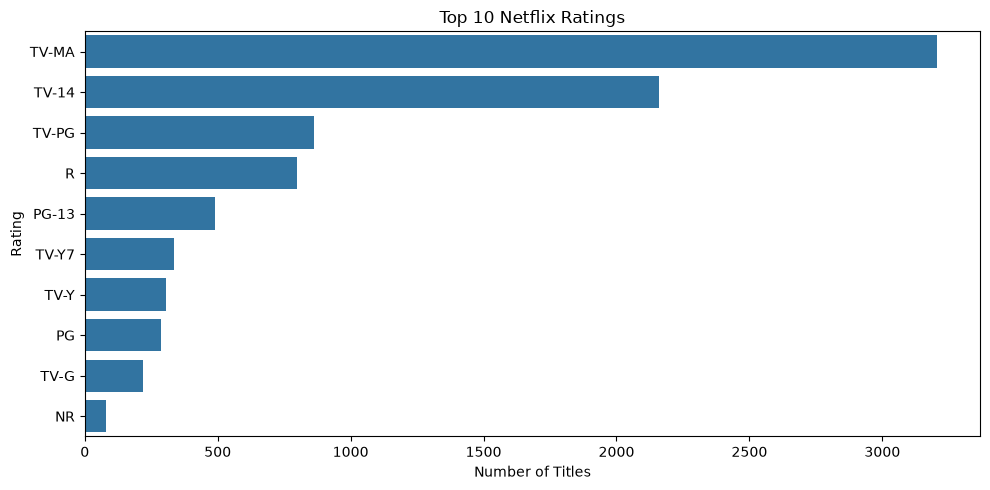

In [40]:
plt.figure(figsize=(10,5))

rating_counts = df["rating"].value_counts().head(10)

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Top 10 Netflix Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()

plt.savefig("images/top_ratings.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

## Business Insights

### Key Findings

- Movies represent the majority of Netflix content, making up approximately 69.6% of the catalog.
- The United States is the largest content producer on Netflix, followed by India and the United Kingdom.
- Netflix content growth increased significantly between 2016 and 2020, with 2018 having the highest number of releases.
- International Movies and Dramas are the most common genres on the platform.
- TV-MA is the most frequent rating, showing Netflix has a strong focus on mature audiences.

## Conclusion

This project analyzed Netflix content data using Python.

The analysis included data cleaning, exploratory data analysis (EDA), and data visualization to understand Netflix's content strategy.

The findings show that Netflix has a strong focus on movies, international content, drama genres, and mature audience programming.

These insights help understand content trends and audience preferences on the platform.
